In [365]:
import signal_gen_toolbox as sgt

import importlib
importlib.reload(sgt)

fn_yaml = "config.yaml"

N_loadcases = 100


In [366]:
config = sgt.load_config(fn_yaml)

{'signals': {'sig1': {'display_name': 'signal_1',
                      'units': 'F',
                      'parameters': {'magnitude': {'distribution_type': 'uniform',
                                                   'min_value': 0,
                                                   'max_value': 100},
                                     'rate_of_change': {'distribution_type': 'uniform',
                                                        'min_value': -10,
                                                        'max_value': 10,
                                                        'set_to_0_probability': 0.3}},
                      'plot_color': 'red'},
             'sig2': {'display_name': 'signal_2',
                      'units': 'F',
                      'parameters': {'magnitude': {'distribution_type': 'uniform',
                                                   'min_value': 0,
                                                   'max_value': 200},
                      

In [367]:
samples = sgt.generate_samples(config, N = N_loadcases)
samples

{'signals': {'sig1': {'magnitude': array([ 79.7979798 ,  58.58585859,  76.76767677,  92.92929293,
           23.23232323,  51.51515152,  82.82828283,  98.98989899,
           70.70707071,  10.1010101 ,   7.07070707,  31.31313131,
           90.90909091,  67.67676768,  39.39393939,  71.71717172,
           42.42424242,  27.27272727,  15.15151515,  21.21212121,
           13.13131313,  74.74747475,  43.43434343,  68.68686869,
           44.44444444,   1.01010101,  30.3030303 ,  88.88888889,
           50.50505051,  77.77777778,  11.11111111,  66.66666667,
           95.95959596,  87.87878788,  81.81818182,   6.06060606,
           85.85858586,  52.52525253,  40.4040404 ,  83.83838384,
           34.34343434,  38.38383838,  91.91919192,   8.08080808,
           24.24242424,  93.93939394, 100.        ,  54.54545455,
           37.37373737,  55.55555556,  32.32323232,  73.73737374,
           22.22222222,  28.28282828,  96.96969697,   4.04040404,
           48.48484848,  94.94949495,  36.36

In [368]:
idx = 0

df_signals, df_parameters = sgt.generate_ramp_signals(samples, config, idx)

print(df_signals)
print(df_parameters)



                 sig1       sig2        sig3        sig4       sig5
t                                                                  
0.000000     79.79798  44.444444  269.696970   35.353535   79.79798
7.181818     79.79798  44.444444  269.696970   35.353535   79.79798
9.243674    100.00000  28.407789  188.472352   71.592211  100.00000
12.896104   100.00000   0.000000   44.588745  100.000000  100.00000
14.027972   100.00000   0.000000    0.000000  100.000000  100.00000
22.838384   100.00000   0.000000    0.000000  100.000000  100.00000
29.909091   100.00000   0.000000    0.000000  100.000000  100.00000
38.719503   100.00000   0.000000    0.000000  100.000000  100.00000
39.851371   100.00000   0.000000   44.588745  100.000000  100.00000
43.503801   100.00000  28.407789  188.472352   71.592211  100.00000
45.565657    79.79798  44.444444  269.696970   35.353535   79.79798
200.000000   79.79798  44.444444  269.696970   35.353535   79.79798
      initial_value  ramp_start_time  ramp_durat

In [369]:


import pandas as pd

df_all = pd.DataFrame(index = range(N_loadcases), columns = ['loadcase_name', 'df_signals', 'df_parameters'])

for i in range(N_loadcases):
    loadcase_name = f"ramp_{i+1:05d}"
    df_signals, df_parameters = sgt.generate_ramp_signals(samples, config, i)
    df_all.loc[i,  ['loadcase_name', 'df_signals', 'df_parameters']] = [loadcase_name, df_signals, df_parameters]

print(df_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   loadcase_name  100 non-null    object
 1   df_signals     100 non-null    object
 2   df_parameters  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB
None


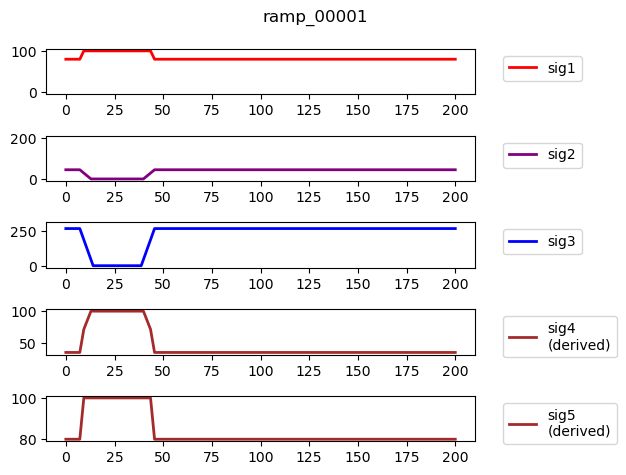

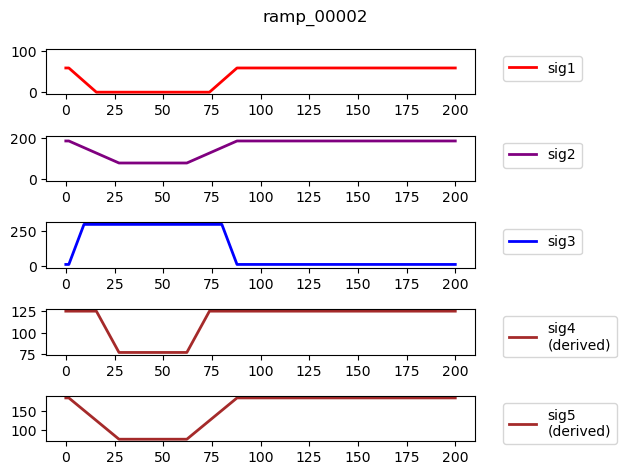

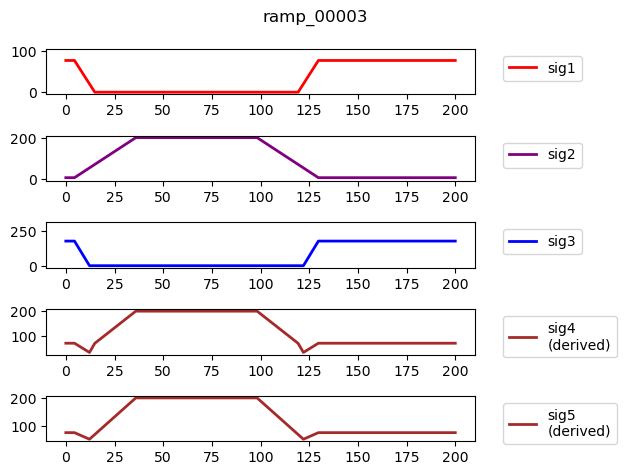

In [370]:
for i in range(3):
    loadcase_name = df_all.loc[i, 'loadcase_name']
    df_signals = df_all.loc[i, 'df_signals']
    sgt.plot_loadcase(df_signals, config, loadcase_name = loadcase_name)